In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

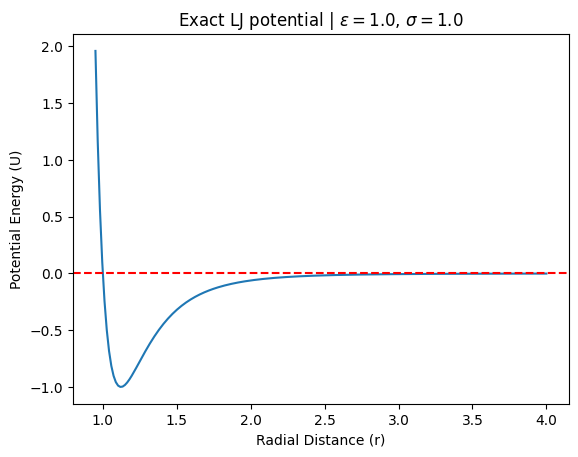

In [2]:
# generating data for LJ potential
ep = 1.0
sigma = 1.0
r = torch.linspace(0.95,4.0,200,requires_grad=True).reshape(-1,1)
with torch.no_grad():
    U_exact = 4*ep*((sigma/r)**12 - (sigma/r)**6)

# visualising the correct LJ potential
plt.plot(r.flatten().detach(),U_exact.flatten().detach())
plt.axhline(0,ls = '--',c='red')
plt.title(f'Exact LJ potential | $\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.show()

In [3]:
# defining the NN model
# the model will take 'r' as input and return 'U'
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [4]:
# loss function
def Loss(model,r):
    U = model(r)
    return torch.mean((U-U_exact)**2)

In [5]:
# optimizer
optim = torch.optim.Adam(model.parameters(),lr = 0.01)

In [6]:
# training the model
N_epochs = 100000
loss_arr = []
for epoch in range(N_epochs):
    loss = Loss(model,r)
    loss_arr.append(loss.item())
    loss.backward()
    optim.step()
    optim.zero_grad()

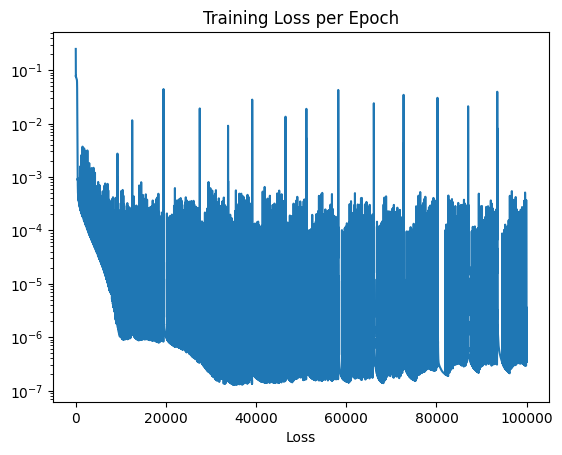

In [7]:
# visualising loss
plt.semilogy(loss_arr)
plt.xlabel('Epoch')
plt.xlabel('Loss')
plt.title('Training Loss per Epoch')
plt.show()

In [8]:
U_nn = model(r)

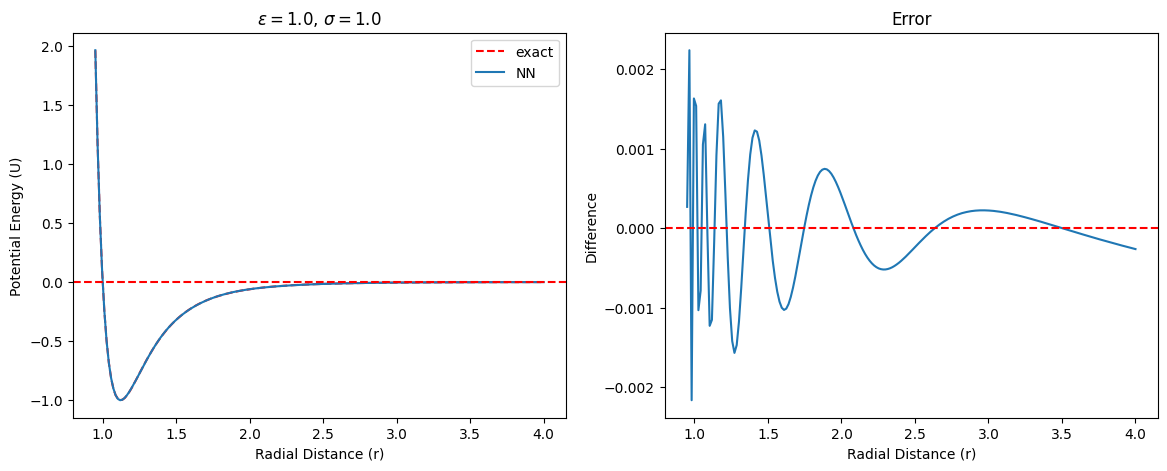

In [9]:
# visualising the correct and nn-predicted LJ potential

plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(r.flatten().detach(),U_exact.flatten().detach(),c='red',ls = '--',label = 'exact')
plt.plot(r.flatten().detach(),U_nn.flatten().detach(),label = 'NN')
plt.axhline(0,ls = '--',c='red')
plt.title(f'$\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(r.flatten().detach(),(U_nn-U_exact).flatten().detach())
plt.axhline(0,ls = '--',c='red')
plt.title(f'Error')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Difference')
plt.show()

### Remarks :

1. ReLU activation performs badly on this problem. Loss cannot diminish after a threshold.

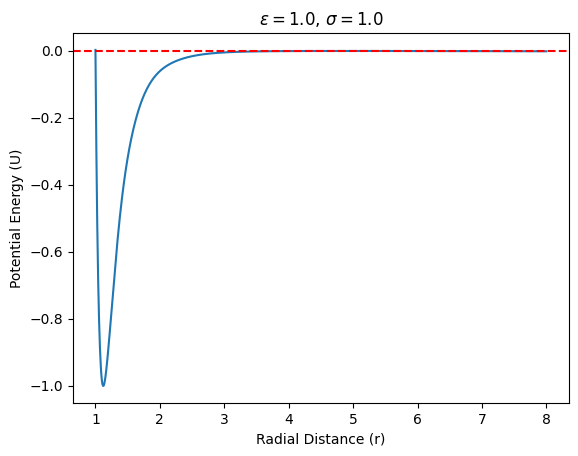

In [10]:
# beyond training region

r_beyond = torch.linspace(1.0,8.0,1000).reshape(-1,1)
y_beyond = model(r_beyond)
plt.plot(r_beyond.flatten().detach(),y_beyond.flatten().detach())
plt.axhline(0,c='red',ls = '--')
plt.title(f'$\epsilon = ${ep}, $\sigma = ${sigma}')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Potential Energy (U)')
plt.show()

### Comparing the Forces

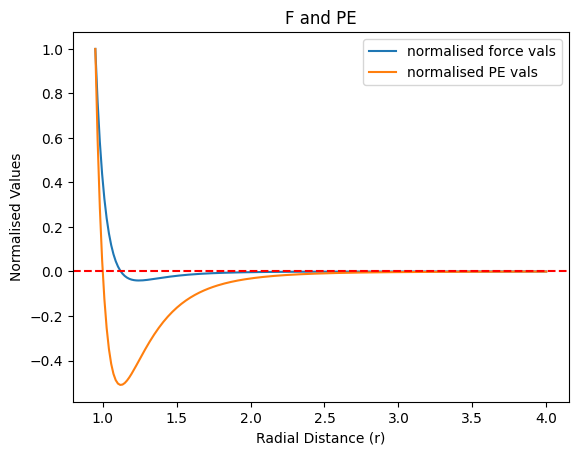

In [11]:
F_exact = 4*ep*(12*(sigma/r)**12/r - 6*(sigma/r)**6/r)
plt.plot(r.flatten().detach(),(F_exact/max(F_exact)).flatten().detach(),label = 'normalised force vals')
plt.plot(r.flatten().detach(),(U_exact/max(U_exact)).flatten().detach(),label = 'normalised PE vals')
plt.axhline(0,c='red',ls='--')
plt.title('F and PE')
plt.xlabel('Radial Distance (r)')
plt.ylabel('Normalised Values')
plt.legend()
plt.show()

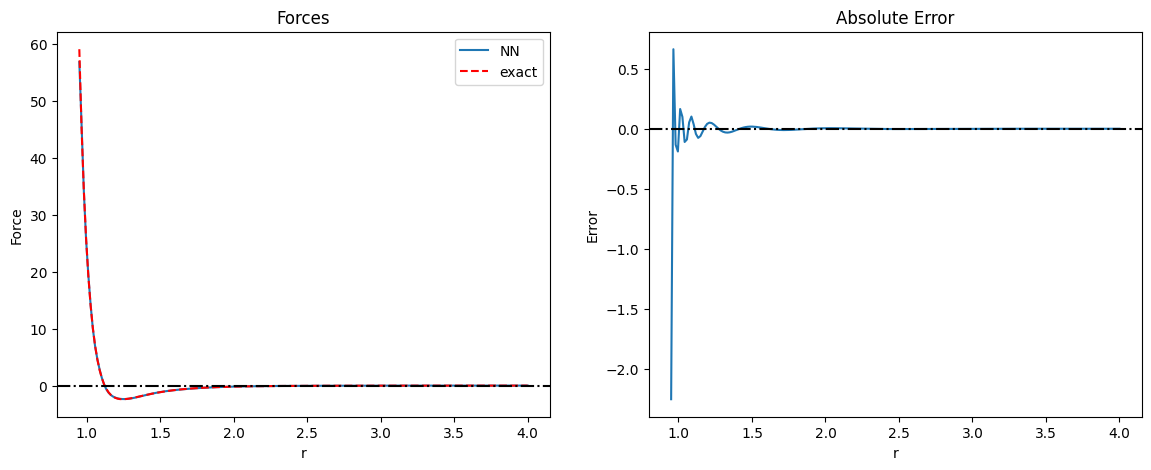

In [12]:
# using automatic differentiation
F_nn = -torch.autograd.grad(
    outputs=U_nn,
    inputs=r,
    create_graph=True,
    grad_outputs=torch.ones_like(U_nn)
)[0]

plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(r.flatten().detach(),F_nn.flatten().detach(),label = 'NN')
plt.plot(r.flatten().detach(),F_exact.flatten().detach(),label = 'exact',c='red',ls = '--')
plt.axhline(0,ls = '-.',c='k')
plt.title('Forces')
plt.xlabel('r')
plt.ylabel('Force')
plt.legend()

plt.subplot(1,2,2)
plt.plot(r.flatten().detach(),(F_nn-F_exact).flatten().detach())
plt.axhline(0,ls = '-.',c='k')
plt.title('Absolute Error')
plt.xlabel('r')
plt.ylabel('Error')

plt.show()

## MD Simulation using the trained NN

In [13]:
# some parameters
N_particles = 49              # number of particles
m = 1.0                       # mass
ep = 1.0                      # epsilon (in LJ potential)
sigma = 1.0                   # sigma (in LJ potential)

In [14]:
def compute(pos, momenta):
    pos = pos.clone().detach().requires_grad_(True)
    U = 0.0
    for i in range(N_particles):
        for j in range(i + 1, N_particles):
            r_ij = pos[i] - pos[j]
            dist = torch.linalg.norm(r_ij).reshape(1, 1)

            U += model(dist).squeeze()

    F_arr = -torch.autograd.grad(
        outputs=U,
        inputs=pos,
        create_graph=False
    )[0]

    K = torch.sum(0.5 * momenta**2 / m)

    return K, U.detach(), (K + U.detach()), F_arr.detach()

In [15]:
# initializing positions and momenta
# we shall initialize the positions on a grid with small fluctuations
torch.manual_seed(10)

a = 1.3*sigma
arr = torch.arange(7,dtype = torch.float32)*a
X,Y = torch.meshgrid(arr,arr)
pos_ini = torch.column_stack((X.ravel(),Y.ravel())) + 0.1*torch.randn(N_particles,2)

momenta_ini = torch.rand((N_particles,2))

# removing center of mass momenta
# this is done to ensure that the pseudo-box remains still
momenta_ini -= torch.mean(momenta_ini,axis = 0)

C:\Users\ANUNAY CHANDRA\AppData\Roaming\Python\Python310\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [16]:
# writing the solver part
t0,tf,h = 0.0,5.0,0.001
N = int((tf-t0)/h)+1

pos_arr = torch.zeros((N,N_particles,2),dtype=torch.float32)
momenta_arr = torch.zeros((N,N_particles,2),dtype=torch.float32)
pos_arr[0] = pos_ini
momenta_arr[0] = momenta_ini

KE_arr = torch.zeros((N,),dtype=torch.float32)
PE_arr = torch.zeros((N,),dtype=torch.float32)
TE_arr = torch.zeros((N,),dtype=torch.float32)
F_arr = torch.zeros((N,N_particles,2),dtype=torch.float32)

KE_arr[0],PE_arr[0],TE_arr[0],F_arr[0] = compute(pos_ini,momenta_ini)


for i in range(N-1):    
    # second order symplectic method
    pos_half = pos_arr[i] + 0.5*h*momenta_arr[i]/m
    _,_,_,F_half = compute(pos_half,momenta_ini)             # note that any momenta will work for this line
    momenta_arr[i+1] = momenta_arr[i] + h*F_half
    pos_arr[i+1] = pos_half + 0.5*h*momenta_arr[i+1]/m

    KE_arr[i+1],PE_arr[i+1],TE_arr[i+1],F_arr[i+1] = compute(pos_arr[i+1],momenta_arr[i+1])

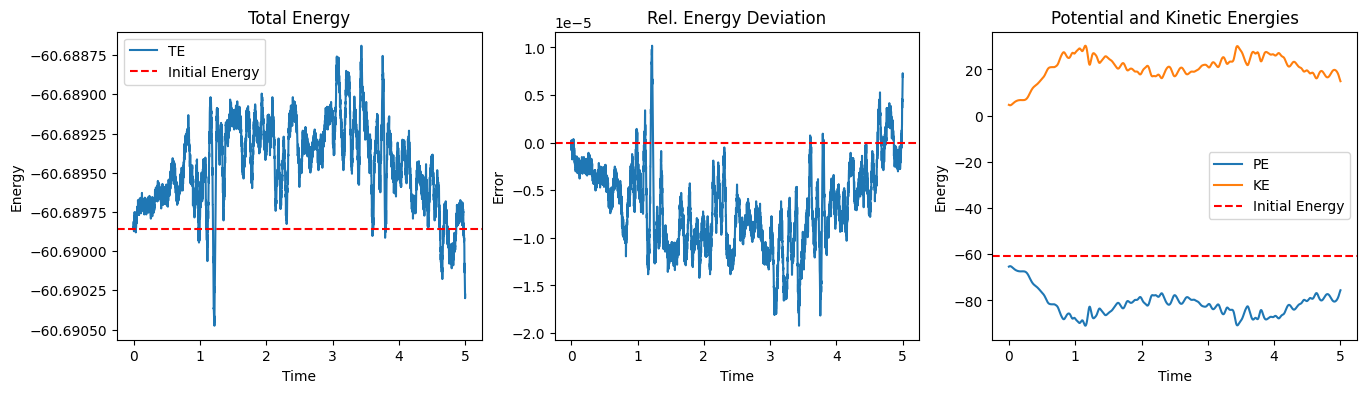

In [17]:
# checking the energy of the system
t_arr = torch.linspace(t0,tf,N)
plt.figure(figsize = (16,4))
plt.subplot(1,3,1)
plt.plot(t_arr,TE_arr,label = 'TE')
plt.title("Total Energy")
plt.xlabel('Time')
plt.ylabel('Energy')
plt.axhline(TE_arr[0],ls = '--',c = 'red',label = 'Initial Energy')
plt.legend()
plt.subplot(1,3,2)
plt.plot(t_arr,(TE_arr-TE_arr[0])/TE_arr[0])
plt.title("Rel. Energy Deviation")
plt.xlabel('Time')
plt.ylabel('Error')
plt.axhline(0,ls = '--',c = 'red')
plt.subplot(1,3,3)
plt.plot(t_arr,PE_arr,label = 'PE')
plt.plot(t_arr,KE_arr,label = 'KE')
plt.title("Potential and Kinetic Energies")
plt.xlabel('Time')
plt.ylabel('Energy')
plt.axhline(TE_arr[0],ls = '--',c = 'red',label = 'Initial Energy')
plt.legend()
plt.show()

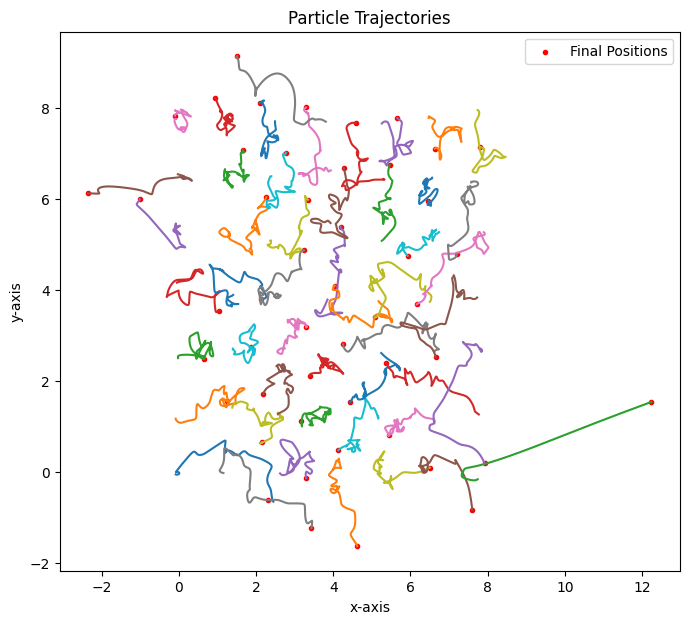

In [18]:
N_show = 49                     # <= N_particles
plt.figure(figsize = (8,7))
plt.scatter(pos_arr[-1,:N_show,0],pos_arr[-1,:N_show,1],label = 'Final Positions',marker = '.',c='r')
for i in range(N_show):
    plt.plot(
        pos_arr[:,i,0],
        pos_arr[:,i,1]
    )
plt.title("Particle Trajectories")
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.show()

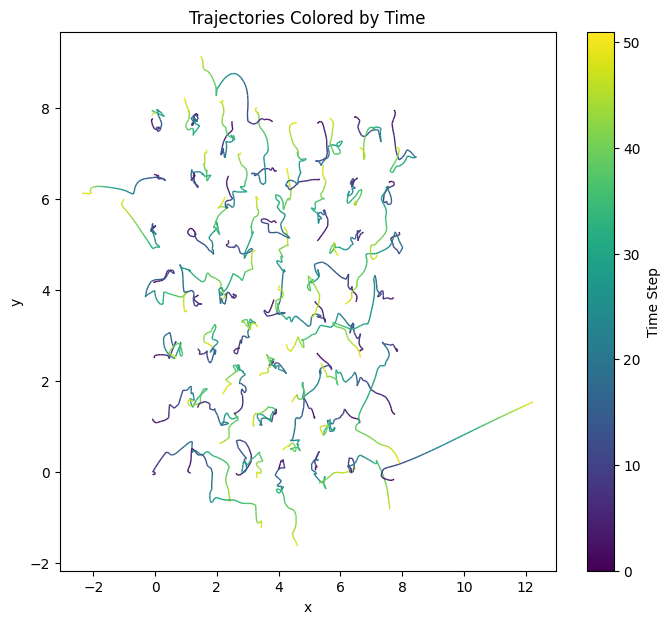

In [19]:
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib.pyplot as plt

stride = 100   # plot every 100th time step to avoid freezing

fig, ax = plt.subplots(figsize=(8, 7))

for particle in range(N_particles):

    x = pos_arr[::stride, particle, 0].detach().numpy()
    y = pos_arr[::stride, particle, 1].detach().numpy()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(
        segments,
        cmap="viridis",
        norm=plt.Normalize(0, len(x))
    )

    lc.set_array(np.arange(len(x) - 1))
    lc.set_linewidth(1.0)

    ax.add_collection(lc)

ax.autoscale()

plt.colorbar(lc, ax=ax, label="Time Step")
plt.title("Trajectories Colored by Time")
plt.xlabel("x")
plt.ylabel("y")
plt.show()